In [2]:
!pip install kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d karaagroaiprojects/cadi-ai -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/karaagroaiprojects/cadi-ai
License(s): GNU Affero General Public License 3.0


In [4]:
#%% [code]
# Imports and dependencies
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import itertools
import time

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [5]:
#%% [code]
# Custom dataset class to load images and extract labels from YOLO annotation files.
class CashewDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        """
        Args:
            images_dir (str): Directory with images.
            labels_dir (str): Directory with YOLO-format label files.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        # List image files (assuming images have extensions like .jpg, .jpeg, or .png)
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.image_files.sort()  # Ensure consistent ordering

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_filename = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_filename)
        # Open image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        # Apply transformation if provided
        if self.transform:
            image = self.transform(image)

        # Assume the label file has the same basename with .txt extension.
        label_filename = os.path.splitext(img_filename)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_filename)
        # Read the file and extract the first class label (YOLO format: "class x_center y_center width height")
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            if len(lines) > 0:
                label = int(lines[0].split()[0])
            else:
                label = 0  # default label if file is empty
        else:
            label = 0  # default label if file not found

        return image, label


In [6]:
#%% [code]
# Define data transforms and directories.
# EfficientNet-B0 standard input size is 224x224.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# Update these paths according to your dataset structure in Colab.
train_images_dir = "/content/Data/train/train/images"
train_labels_dir = "/content/Data/train/train/labels"
val_images_dir = "/content/Data/val/val/images"
val_labels_dir = "/content/Data/val/val/labels"

# Create datasets and dataloaders.
train_dataset = CashewDataset(train_images_dir, train_labels_dir, transform=data_transforms['train'])
val_dataset   = CashewDataset(val_images_dir, val_labels_dir, transform=data_transforms['val'])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Train samples: 2721, Validation samples: 525


In [7]:
#%% [code]
# Create the EfficientNet-B0 model using torchvision.
# Modify the classifier to output 3 classes: ['abiotic', 'insect', 'disease']
num_classes = 3
model = models.efficientnet_b0(pretrained=True)
# The classifier is typically a Sequential with the last layer as a Linear layer.
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 75.0MB/s]


In [8]:
#%% [code]
# Define loss function and optimizer.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [9]:
#%% [code]
# Training loop with metric calculations.
num_epochs = 10  # Adjust number of epochs as needed.
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# For overall metric calculations on validation set.
all_val_labels = []
all_val_preds = []

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    epoch_val_labels = []
    epoch_val_preds = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            epoch_val_labels.extend(labels.cpu().numpy())
            epoch_val_preds.extend(preds.cpu().numpy())

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    all_val_labels.extend(epoch_val_labels)
    all_val_preds.extend(epoch_val_preds)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} | "
          f"Time: {elapsed:.2f}s")

# Overall validation metrics.
val_acc = accuracy_score(all_val_labels, all_val_preds)
val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
val_recall = recall_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
cm = confusion_matrix(all_val_labels, all_val_preds)

print("\nValidation Metrics:")
print("Accuracy: {:.4f}".format(val_acc))
print("Precision: {:.4f}".format(val_precision))
print("Recall: {:.4f}".format(val_recall))
print("F1 Score: {:.4f}".format(val_f1))


Epoch 1/10 | Train Loss: 0.8952 Acc: 0.5906 | Val Loss: 0.6968 Acc: 0.7124 | Time: 170.89s
Epoch 2/10 | Train Loss: 0.6276 Acc: 0.7468 | Val Loss: 0.5773 Acc: 0.7562 | Time: 167.76s
Epoch 3/10 | Train Loss: 0.4579 Acc: 0.8269 | Val Loss: 0.5519 Acc: 0.7924 | Time: 169.62s
Epoch 4/10 | Train Loss: 0.3562 Acc: 0.8673 | Val Loss: 0.5359 Acc: 0.8000 | Time: 183.15s
Epoch 5/10 | Train Loss: 0.2653 Acc: 0.9067 | Val Loss: 0.5450 Acc: 0.7924 | Time: 172.76s
Epoch 6/10 | Train Loss: 0.2233 Acc: 0.9214 | Val Loss: 0.6659 Acc: 0.8038 | Time: 171.15s
Epoch 7/10 | Train Loss: 0.1866 Acc: 0.9324 | Val Loss: 0.7064 Acc: 0.7905 | Time: 169.25s
Epoch 8/10 | Train Loss: 0.1423 Acc: 0.9530 | Val Loss: 0.6942 Acc: 0.7867 | Time: 168.14s
Epoch 9/10 | Train Loss: 0.1301 Acc: 0.9548 | Val Loss: 0.6763 Acc: 0.7886 | Time: 169.41s
Epoch 10/10 | Train Loss: 0.1166 Acc: 0.9541 | Val Loss: 0.7544 Acc: 0.7905 | Time: 167.45s

Validation Metrics:
Accuracy: 0.7813
Precision: 0.7632
Recall: 0.7684
F1 Score: 0.7647


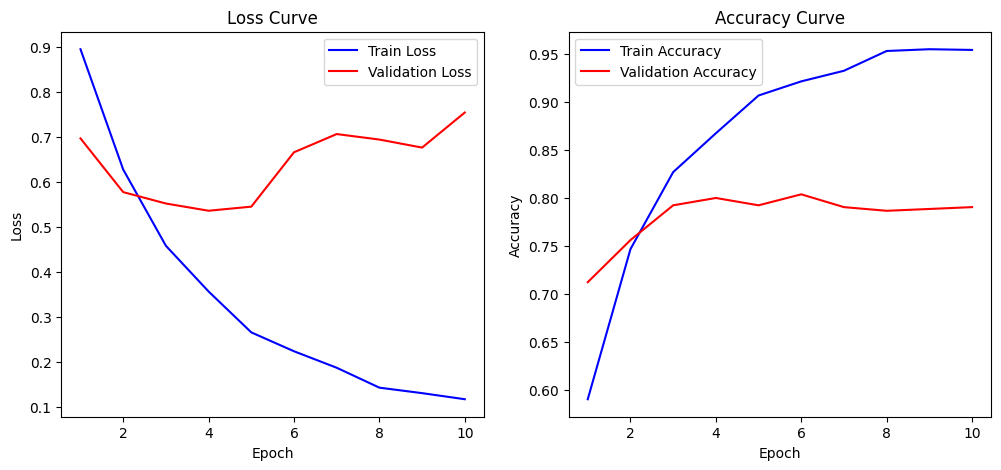

In [10]:
#%% [code]
# Plot training and validation loss and accuracy curves.
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()


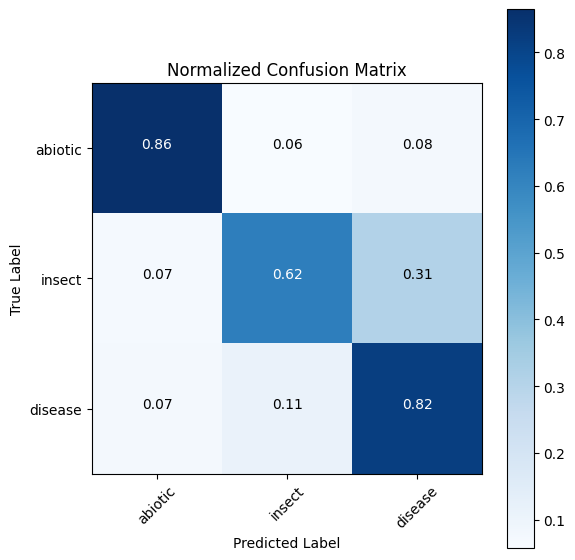

In [11]:
 #%% [code]
# Plot the confusion matrix.
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

class_names = ['abiotic', 'insect', 'disease']
plot_confusion_matrix(cm, classes=class_names, normalize=True, title='Normalized Confusion Matrix')
plt.show()
